# The Average and the Central Limit Theorem

The uniform distribution on an interval $[a, b]$ describes a random variable that is equally likely to take any value in this interval. The probability density function (pdf) of a uniform distribution is given by:

$$
f(x) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}
$$

- Check that the distribution is properly normalized by integrating the pdf over the entire real line (note that this is simply the area of the rectangle defined by the interval $[a, b]$ and height $\frac{1}{b-a}$).
- Calculate the mean and variance of the uniform distribution.

As for any continuous distribution, the expected value and the variance of a random variable $X$ with PDF $f(x)$ are given by:

$$
\mu = E[X] = \int_{-\infty}^{\infty} x f(x) dx
$$

$$
Var(X) = E(X - \mu)^2 = \int_{-\infty}^{\infty} (x - \mu)^2 f(x) dx
$$

- Verify the expressions for the mean and variance by computing the integrals for the uniform distribution. Note that the integrant is zero outside the interval $[a, b]$, so you can restrict the limits of integration to this interval.


$$
E(X) = \frac{a + b}{2}
$$

$$
Var(X) = \frac{(b - a)^2}{12}
$$


[https://www.desmos.com/calculator/cwqbsrgjpr](https://www.desmos.com/calculator/cwqbsrgjpr)



Because of the law of large numbers, we know that the average of a large number of independent and identically distributed (i.i.d.) random variables will be close to the expected value of the distribution. So if we don't know the actual distribution, we can still _estimate_ some aspects of it by looking at the average of a large number of samples.


Let's imagine one player playing a game where the payout is determined by a random draw from the unifrom distribution on the interval $[-1, 1]$. This means that in each game the player has equal chance to win up to 1 Euro or lose up to 1 Euro. We can simulate this game by generating random numbers from the uniform distribution and keeping track of the player's winnings over multiple games. In particular we are interested in the sum of the player's winnings after a certain number of games. Let's say that a player plays 32 games, and we want to see how the sum of the winnings evolves over time. We can simulate this process for many players to see how the distribution of the sum of winnings changes as the number of games increases.

We denote the result of his or her first game by $X_1$, the second game by $X_2$, and so on, up to the 32nd game by $X_{32}$. 

$$
S_n = X_1 + X_2 + \ldots + X_n
$$

The total winnings after the first game is just 

$$
S_1 = X_1
$$. 

After the second game, the total winnings are

$$
S_2 = X_1 + X_2
$$

After the third game, the total winnings are

$$
S_3 = X_1 + X_2 + X_3
$$

We can generalize this to say that after $n$ games, the total winnings are

$$
S_n = X_1 + X_2 + \ldots + X_n
$$





Loading required package: tidyverse

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─

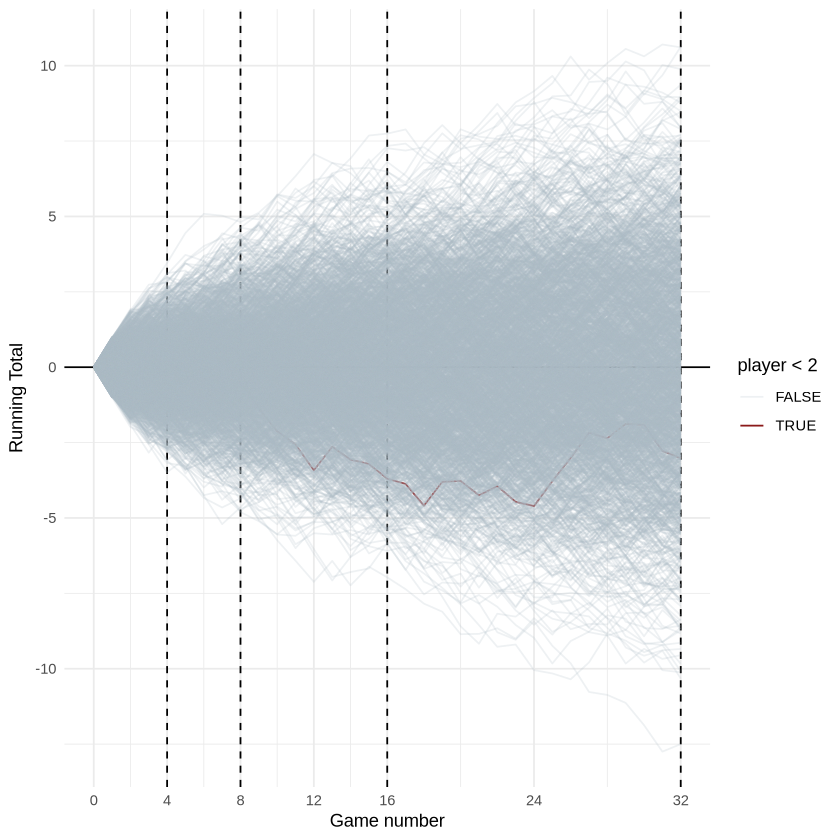

In [1]:
# Load the packages used in this notebook

if (!require("tidyverse")) {
    install.packages("tidyverse")    
}

library(tidyverse)

players_n <- 2000
games_n <- 32

unif_games <- expand_grid(
  game = 1:games_n,
  player = 1:players_n
) %>%
  mutate(
    ## When used in mutate, n() returns the number of rows in a group of obs
    ## When the data is not grouped as here, it retuns the number of obs in the whole table
    result = runif(n(), min = -1, max = 1)
  ) %>%
  bind_rows(
    ## Add a initial values so that all players start with 0
    tibble(
      player = 1:players_n,
      game = 0L,
      result = 0,
    )
  )

unif_games <- unif_games %>%
  ## Sort the data by player id and game id
  arrange(player, game) %>%
  ## Groups the data by player, because we want the running totals to be calculated for each
  ## player separately
  group_by(player) %>%
  mutate(
    running_total = cumsum(result)
  )

## Illustration only
unif_games %>%
  ggplot(aes(x = game, y = running_total, group = player)) +
  geom_vline(xintercept = c(4, 8, 16, 32), linetype = 2) +
  geom_hline(yintercept = 0) +
  geom_line(aes(color = player < 2, alpha = player < 2)) +
  scale_color_manual(values = c("#adbbc518", "firebrick4")) +
  scale_alpha_manual(values = c(1 / 5, 1)) +
  scale_x_continuous("Game number", breaks = c(0, 4, 8, 12, 16, 24, 32)) +
  theme(legend.position = "none") +
  labs(y = "Running Total") +
  theme_minimal()

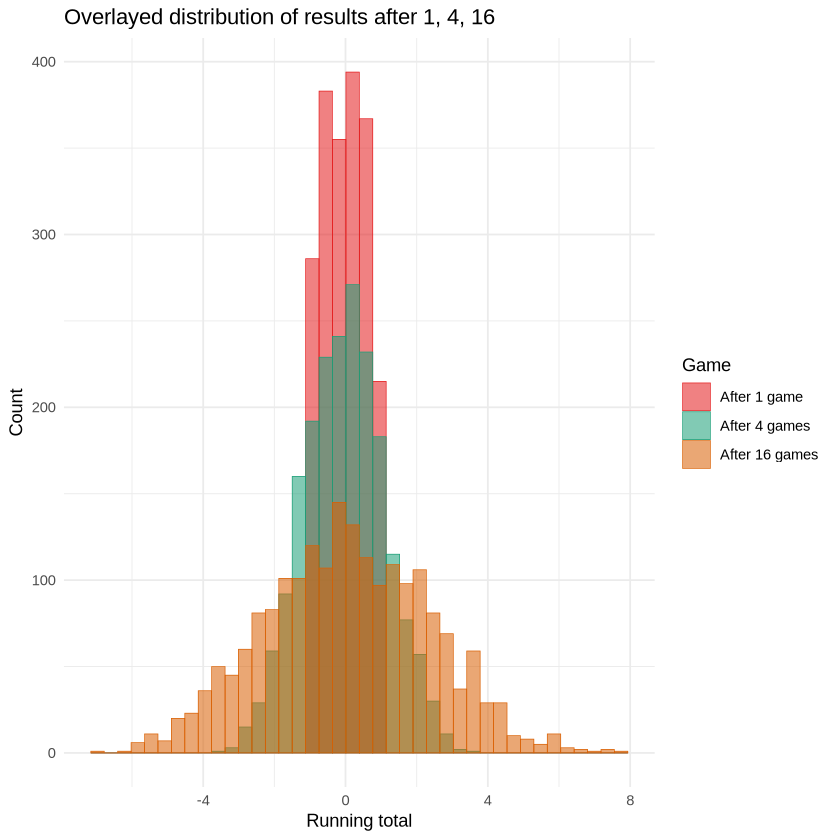

In [2]:
# Overlay of cumulative-result distributions (ggplot version)
dist_snapshot <- unif_games %>%
  ungroup() %>%
  filter(game %in% c(1, 4, 16)) %>%
  mutate(
    game = factor(
      game,
      levels = c(1, 4, 16),
      labels = c("After 1 game", "After 4 games", "After 16 games")
    )
  )

ggplot(dist_snapshot, aes(x = running_total, fill = game, color = game)) +
  geom_histogram(
    position = "identity",
    bins = 40,
    alpha = 0.55,
    linewidth = 0.2
  ) +
  scale_fill_manual(values = c(
    "After 1 game" = "#e41a1c",
    "After 4 games" = "#1b9e77",
    "After 16 games" = "#d95f02"
  )) +
  scale_color_manual(values = c(
    "After 1 game" = "#e41a1c",
    "After 4 games" = "#1b9e77",
    "After 16 games" = "#d95f02"
  )) +
  labs(
    title = "Overlayed distribution of results after 1, 4, 16",
    x = "Running total",
    y = "Count",
    fill = "Game",
    color = "Game"
  ) +
  theme_minimal()

The central limit theorem claims that given a large number of independent samples from a distribution: $X_1, X_2, \ldots, X_n$, the distribution of the standardized sum (or average) of these samples will approach a standard normal distribution as the number of samples increases, regardless of the original distribution of the samples.

$$
\frac{S_n - n\mu}{\sigma \sqrt{n}} \xrightarrow{d} N(0, 1) \quad \text{as } n \to \infty
$$

As the sample average is basically a sum (divided by $n$), it also converges to a normal distribution:

$$
\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0, 1) \quad \text{as } n \to \infty
$$ 

also converges to a normal distribution:

Videos on the Central Limit Theorem and the

{{< video https://www.youtube.com/watch?v=zeJD6dqJ5lo >}}

{{< video https://www.youtube.com/watch?v=cy8r7WSuT1I >}}


## Distribution of the average

[https://www.desmos.com/geometry/k2yatxmvnl](https://www.desmos.com/geometry/k2yatxmvnl)

Properties of the expectation and the variance. Let $X_1, X_2$ be two independent random variables. We will use
the following five properties of the expectation and the variance (without proof).

1. Then the expected value of the sum of these two random variables is:

$$
E(X_1 + X_2) = E(X_1) + E(X_2)
$$

2. For a scaled (multiplied by a constant) random variable, we have:

$$
E(aX) = aE(X)
$$

3. The expected value of a constant is just the constant itself:

$$
E(a) = a
$$


4. The variance of the sum of these two random variables is (independence is important here):
$$
Var(X_1 + X_2) = Var(X_1) + Var(X_2)
$$

5. For a scaled (multiplied by a constant) random variable, we have:

$$
Var(aX) = a^2 Var(X)
$$


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


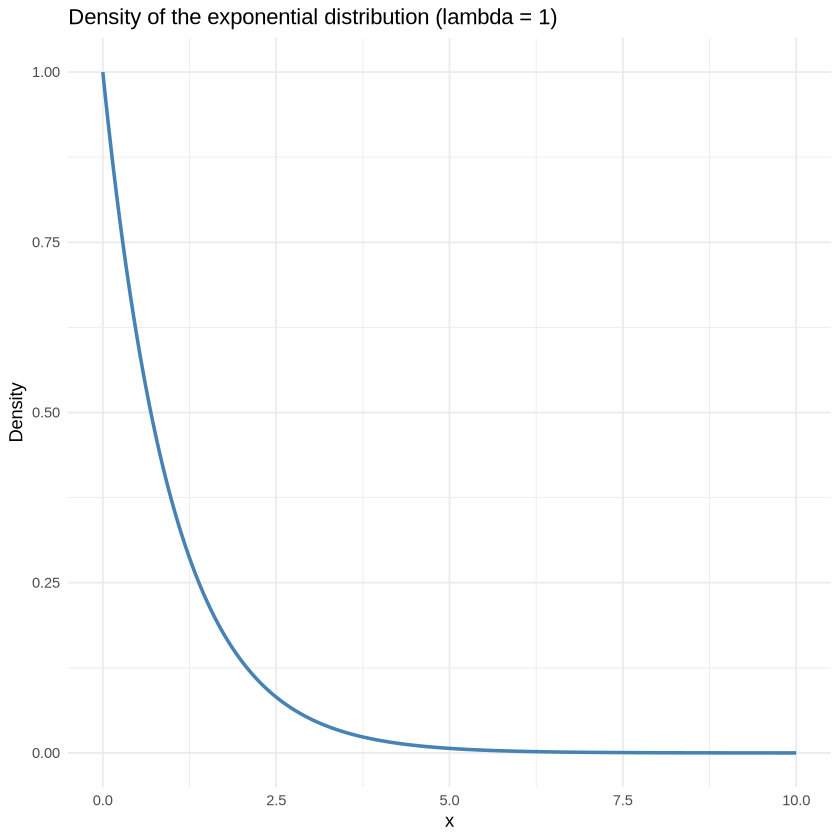

In [3]:
# Plot the exponential density for comparison using ggplot

lambda <- 1
x_vals <- seq(0, 10, length.out = 1000)
exp_density <- dexp(x_vals, rate = lambda)

ggplot(data.frame(x = x_vals, y = exp_density), aes(x = x, y = y)) +
  geom_line(color = "steelblue", size = 1) +
  labs(
    title = "Density of the exponential distribution (lambda = 1)",
    x = "x",
    y = "Density"
  ) +
  theme_minimal()

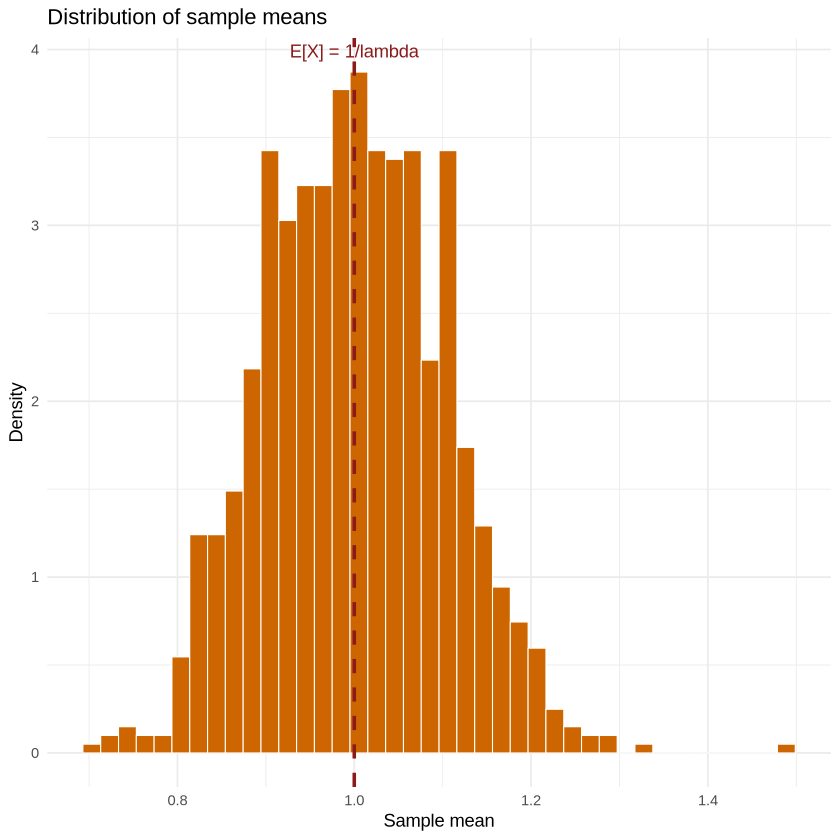

In [5]:
# Simulation: 1000 batches of 100 draws from an exponential distribution

R <- 1000
n <- 100
lambda <- 1

exp_sample_means <- tibble(
  batch = 1:R,
  sample_mean = replicate(R, mean(rexp(n, rate = lambda)))
)

ggplot(exp_sample_means, aes(x = sample_mean)) +
  geom_histogram(
    aes(y = after_stat(density)),
    bins = 40,
    fill = "darkorange3",
    color = "white",
    linewidth = 0.3
  ) +
  geom_vline(
    xintercept = 1 / lambda,
    linetype = "dashed",
    color = "firebrick4",
    linewidth = 1
  ) +
  annotate(
    "text",
    x = 1 / lambda,
    y = Inf,
    label = "E[X] = 1/lambda",
    vjust = 1.5,
    color = "firebrick4"
  ) +
  labs(
    title = "Distribution of sample means",
    x = "Sample mean",
    y = "Density"
  ) +
  theme_minimal()